In [1]:
# EDA on NASA IMS Bearing Dataset
## Test 1: First file (healthy start)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/home/framg/dev/anomalitor/data/nasa/raw/1st_test/1st_test/2003.10.22.12.59.13"

df = pd.read_csv(file_path, 
                 sep='\t',           # ← קריטי! המפריד הוא טאב
                 header=None, 
                 names=["B1_X", "B1_Y", "B2_X", "B2_Y", 
                        "B3_X", "B3_Y", "B4_X", "B4_Y"])

print(df.shape)
df.head()

(20480, 8)


,B1_X,B1_Y,B2_X,B2_Y,B3_X,B3_Y,B4_X,B4_Y
0,-0.186,-0.081,-0.039,-0.166,-0.056,-0.024,-0.103,-0.132
1,-0.188,-0.037,-0.212,-0.193,-0.029,-0.151,-0.056,-0.164
2,-0.171,-0.112,-0.188,-0.237,-0.059,-0.007,-0.044,-0.083
3,-0.159,-0.090,-0.110,-0.227,-0.127,-0.051,-0.154,-0.107
4,-0.144,-0.198,-0.127,-0.171,-0.129,-0.085,-0.149,-0.090


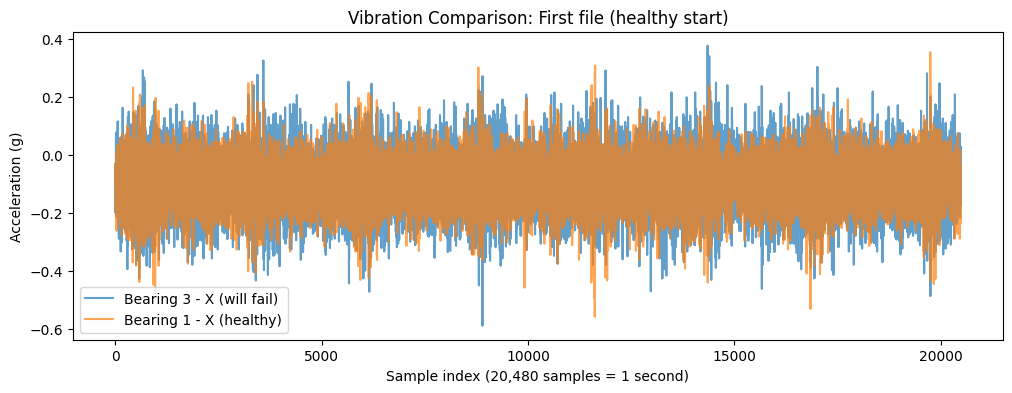

In [3]:
plt.figure(figsize=(12,4))
plt.plot(df["B3_X"], label="Bearing 3 - X (will fail)", alpha=0.7)
plt.plot(df["B1_X"], label="Bearing 1 - X (healthy)", alpha=0.7)
plt.legend()
plt.title("Vibration Comparison: First file (healthy start)")
plt.xlabel("Sample index (20,480 samples = 1 second)")
plt.ylabel("Acceleration (g)")
plt.show()

In [4]:
import numpy as np

# חישוב RMS למיסב 1 (תקין) ומיסב 3 (יכשל)
rms_b1 = np.sqrt(np.mean(df["B1_X"]**2))
rms_b3 = np.sqrt(np.mean(df["B3_X"]**2))

print(f"RMS Bearing 1 (healthy): {rms_b1:.4f} g")
print(f"RMS Bearing 3 (will fail): {rms_b3:.4f} g")
print(f"Ratio (B3/B1): {rms_b3/rms_b1:.4f}")

RMS Bearing 1 (healthy): 0.1248 g
RMS Bearing 3 (will fail): 0.1314 g
Ratio (B3/B1): 1.0529


In [7]:
import pandas as pd
import os
from pathlib import Path

# נתיב אבסולוטי (תמיד עובד)
file_path = "/home/framg/dev/anomalitor/data/nasa/processed/set1_features.csv"
df_features = pd.read_csv(file_path)
from pathlib import Path
print(df_features.head())
print(df_features.tail())
print(f"Total records: {len(df_features)}")
print(f"Current working directory: {os.getcwd()}")
print(f"Home directory: {Path.home()}")

             timestamp    rms_b1    rms_b3     ratio
0  2003.10.22.12.06.24  0.124614  0.128887  1.034292
1  2003.10.22.12.09.13  0.123811  0.129562  1.046449
2  2003.10.22.12.14.13  0.125246  0.131339  1.048644
3  2003.10.22.12.19.13  0.125197  0.131083  1.047008
4  2003.10.22.12.24.13  0.125618  0.131307  1.045290
                timestamp    rms_b1    rms_b3     ratio
2151  2003.11.25.16.07.32  0.168639  0.275645  1.634525
2152  2003.11.25.23.13.21  0.174975  0.496173  2.835683
2153  2003.11.25.23.19.56  0.174571  0.531569  3.045006
2154  2003.11.25.23.29.56  0.173471  0.474447  2.735017
2155  2003.11.25.23.39.56  0.174181  0.593610  3.407998
Total records: 2156
Current working directory: /home/framg/dev/anomalitor/notebooks
Home directory: /home/framg
